# 1.Importing Datasets

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from torch.optim.lr_scheduler import StepLR

# 2. Data loading & Visualization

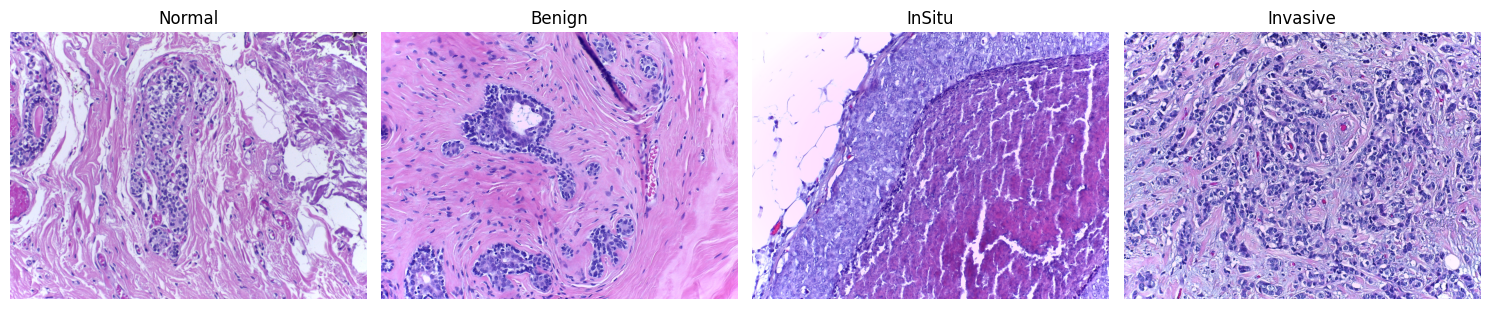

In [2]:
class_names = ["Normal", "Benign", "InSitu", "Invasive"]  
root_dir = "/kaggle/input/bach-a-microscopy-images/Photos"  

plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(root_dir, class_name)
    sample_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, sample_file)
    img = Image.open(img_path).convert('RGB')
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(f'{class_name}')
    plt.axis('off')
plt.tight_layout()
plt.show()


# 3. Setting image sizes

In [3]:
def load_image(path, size=(224, 224)):
    img = Image.open(path).convert('RGB')
    img = img.resize(size)
    img = np.array(img).astype(np.float32) / 255.0
    img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
    img = np.transpose(img, (2, 0, 1))
    return img
# Added after load_image function
train_augmentation = transforms.Compose([
    transforms.ToPILImage(),  # Convert tensor to PIL
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAutocontrast(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_augmentation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 4. Dataset preparation

In [4]:
images = []
labels = []
#Loop to load images:
for label_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(root_dir, class_name)
    for fname in os.listdir(class_dir):
        if fname.endswith('.tif'):
            img_path = os.path.join(class_dir, fname)
            img = load_image(img_path)
            images.append(img)
            labels.append(label_idx)

images_tensor = torch.tensor(np.array(images), dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.long)

# Split into training and test sets(80/20):
X_train, X_test, y_train, y_test = train_test_split(
    images_tensor, labels_tensor, 
    test_size=0.2, 
    random_state=42,
    stratify=labels_tensor
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 320
Test size: 80


# 5. Model Setup

In [5]:
#Mentioning Model for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=True)

# Freezed feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replaced classifier head
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, 4)
)
model = model.to(device)

# Training setup
batch_size = 25
learning_rate = 30e-4
epochs = 40

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-4
)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


# 6.Training Loop

Epoch 1/40 — Loss: 1.1155, Accuracy: 55.31%
Epoch 2/40 — Loss: 0.7299, Accuracy: 72.81%
Epoch 3/40 — Loss: 0.5381, Accuracy: 80.00%
Epoch 4/40 — Loss: 0.5300, Accuracy: 80.00%
Epoch 5/40 — Loss: 0.3932, Accuracy: 86.25%
Epoch 6/40 — Loss: 0.3936, Accuracy: 87.50%
Epoch 7/40 — Loss: 0.3522, Accuracy: 89.69%
Epoch 8/40 — Loss: 0.3161, Accuracy: 90.00%
Epoch 9/40 — Loss: 0.3470, Accuracy: 86.88%
Epoch 10/40 — Loss: 0.3004, Accuracy: 89.38%
Epoch 11/40 — Loss: 0.3149, Accuracy: 88.44%
Epoch 12/40 — Loss: 0.2303, Accuracy: 93.12%
Epoch 13/40 — Loss: 0.2581, Accuracy: 90.94%
Epoch 14/40 — Loss: 0.2595, Accuracy: 90.31%
Epoch 15/40 — Loss: 0.2552, Accuracy: 89.69%
Epoch 16/40 — Loss: 0.2675, Accuracy: 88.12%
Epoch 17/40 — Loss: 0.2545, Accuracy: 91.88%
Epoch 18/40 — Loss: 0.2730, Accuracy: 90.00%
Epoch 19/40 — Loss: 0.2722, Accuracy: 89.69%
Epoch 20/40 — Loss: 0.2207, Accuracy: 93.12%
Epoch 21/40 — Loss: 0.2586, Accuracy: 90.31%
Epoch 22/40 — Loss: 0.2178, Accuracy: 92.50%
Epoch 23/40 — Loss:

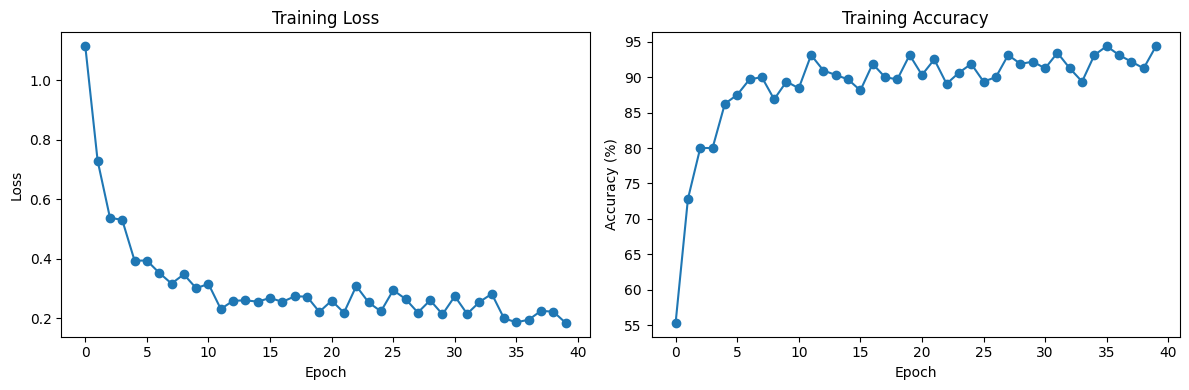

In [6]:
train_losses = []
train_accs = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
# Looping over the batches of data:
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
# Calculating average loss and accuracy:
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} — "
          f"Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_acc:.2f}%")
    
    scheduler.step()
#Finding average
average_acc = sum(train_accs) / len(train_accs)
average_loss = sum(train_losses) / len(train_losses)

print("\n==============================")
print(f"Average Training Accuracy over {epochs} epochs: {average_acc:.2f}%")
print(f"Average Training Loss over {epochs} epochs: {average_loss:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')  
plt.tight_layout()
plt.show()

# 7. Evaluation & Confusion Matrix

Test Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.95      0.88        20
      Benign       0.85      0.55      0.67        20
      InSitu       0.89      0.80      0.84        20
    Invasive       0.73      0.95      0.83        20

    accuracy                           0.81        80
   macro avg       0.82      0.81      0.80        80
weighted avg       0.82      0.81      0.80        80



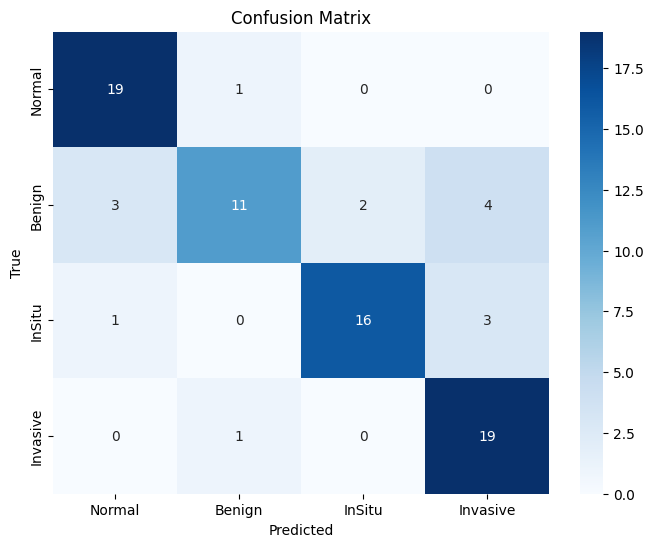

In [7]:
# added this test evaluation block
def tta_predict(model, input_tensor):
    # """Test-Time Augmentation for robustness"""
    # Original
    outputs = model(input_tensor.unsqueeze(0))
    # Horizontal flip
    outputs += model(torch.flip(input_tensor, [2]).unsqueeze(0))
    # Vertical flip
    outputs += model(torch.flip(input_tensor, [1]).unsqueeze(0))
    # Brightness adjustment
    bright_img = torch.clamp(input_tensor * 1.3, 0, 1)
    outputs += model(bright_img.unsqueeze(0))
    # Dark adjustment
    dark_img = torch.clamp(input_tensor * 0.7, 0, 1)
    outputs += model(dark_img.unsqueeze(0))
    
    return outputs / 5.0
# Updated evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        for i in range(inputs.size(0)):
            output = tta_predict(model, inputs[i])
            _, pred = torch.max(output, 1)
            all_preds.append(pred.item())
        all_labels.extend(labels.numpy())

print("Test Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Generating confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()